## Afleiding relaties Kosten, volumes en kruinverhoging.

Dit notebook kan worden gebruikt om de relaties tussen kosten, volume en kruinverhoging af te leiden op basis van de analyses van het basispad. Deze zijn input voor het model voor de gevoeligheidsanalyse.

In [1]:
from __future__ import annotations
import pandas as pd
from pathlib import Path
import copy
import os 

from collections import defaultdict
from typing import Any, Dict, Iterable, List, Optional, Union
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
sns.set_style('whitegrid')

#switch dir and load packages
#check if /app is in Path.cwd() and if not, switch to the root of the repo
if 'app' not in [p.name for p in Path.cwd().parents]:
    os.chdir(r'..\..')


from app.dike_components.dike_model import DikeModel
from app.cost_calculator import CostCalculator, DirectCostGroundWork, StructureCosts, InfrastructureCosts
from app.unit_costs_and_surcharges import load_kosten_catalogus
from dev.incremental_costs.utils import get_dimensions_dict_from_df, modified_cost_computation, make_reinforcement_incremental, compute_incremental_volumes, compute_incremental_costs, compute_lcc, lcc_plot, recategorize_cost

# Path of WJK
working_dir = Path(r"c:\Users\klerk_wj\Stichting Deltares\KIA – Aanpasbaar en Uitbreidbaar - Documents\WP3 casestudies\2c WIP casus WSSS\designs toolbox KOSWAT")
# Path of Yida
# working_dir = Path(r"C:\Users\tao\OneDrive - Stichting Deltares\KIA – Aanpasbaar en Uitbreidbaar - Documents\WP3 casestudies\2c WIP casus WSSS\designs toolbox KOSWAT")

sns.set_palette("husl", 12)
colors = sns.color_palette("husl", 12)




### Afleiding voor grondversterking
Als eerste leiden we de K(V) en V(dH) relaties af voor grondversterkingen.

In [2]:
## SETTINGS ## 
files = [
    'ontwerpvariant grond gestacked/kostenoverzicht design grond 1.xlsx',
         'ontwerpvariant grond gestacked/kostenoverzicht grond 2 aanlegprofiel.xlsx',
         'ontwerpvariant grond gestacked/kostenoverzicht grond 3 aanlegprofiel.xlsx',
         'ontwerpen kruinverhogingen/kostenoverzicht 50cm.xlsx',
         'ontwerpen kruinverhogingen/kostenoverzicht 100cm.xlsx',
         'ontwerpen kruinverhogingen/kostenoverzicht 150cm.xlsx',
         'ontwerpen kruinverhogingen/kostenoverzicht 200cm.xlsx',]
names = [
"Grondversterking 2025", "Grondversterking 2075", "Grondversterking 2125",
         "Kruinverhoging 50cm", "Kruinverhoging 100cm", "Kruinverhoging 150cm", "Kruinverhoging 200cm"]

alternatives = dict(zip(names, files))

dike = DikeModel(complexity = 'gemiddelde maatregel')

#load costs for all alternatives
cost_dataframes_per_alternative = {}
for name, file in alternatives.items():
    cost_dataframes_per_alternative[name] = pd.read_excel(working_dir / file, sheet_name='Kosten')

#dimensions for all alternatives
dimensions = {}
for name, df in cost_dataframes_per_alternative.items():
    dimensions[name] = get_dimensions_dict_from_df(df)

#recomputation of plain costs for all alternatives
cost_summaries = {}
full_cost_dicts = {}
new_dimensions = {}
for name, dimension in dimensions.items():
    cost_summaries[name], full_cost_dicts[name], new_dimensions[name] = modified_cost_computation(dike, dimension)


df_all_costs = pd.concat(cost_summaries.values(), axis=1)
df_all_costs.columns = cost_summaries.keys()

#add (ruw) to the column names of df_all_costs
df_all_costs.columns = [col + " (ruw)" for col in df_all_costs.columns]

cost_per_increment_summary, cost_per_increment_detailed, dimensions_per_increment = compute_incremental_costs(names, dimensions, dike, print_output=False)

df_all_increments = pd.concat(cost_per_increment_summary.values(), axis=1)
df_all_increments.columns = cost_per_increment_summary.keys()
df_all_increments.columns = [col + " (incrementeel)" for col in df_all_increments.columns]


#merge the incremental costs with the plain costs
df_all_costs_with_increments_soil = pd.concat([df_all_costs, df_all_increments], axis=1)
#add (incrementeel) to the column names of df_all_increments before merging

# We ignore the vastgoedkosten in this case


In [3]:
#make dataframe of dimensions
volume_cost_df_soil = pd.DataFrame.from_dict(new_dimensions, orient='index', columns = ['V1b', 'V2b', 'V3', 'V4', 'V5', 'Kosten (excl. BTW)'])

for name, dims in new_dimensions.items():
    volume_cost_df_soil.loc[name] = [dims['ground']['V1b'], dims['ground']['V2b'], dims['ground']['V3'], dims['ground']['V4'], dims['ground']['V5'], 0.]
    volume_cost_df_soil.loc[name, 'Kosten (excl. BTW)'] = df_all_costs_with_increments_soil[name + " (ruw)"].sum()

for name, dims in dimensions_per_increment.items():
    volume_cost_df_soil.loc[name] = [dims['ground']['V1b'], dims['ground']['V2b'], dims['ground']['V3'], dims['ground']['V4'], dims['ground']['V5'], 0.]
    volume_cost_df_soil.loc[name, 'Kosten (excl. BTW)'] = df_all_costs_with_increments_soil[name + " (incrementeel)"].sum()
#make all values in dimensions_df integers
volume_cost_df_soil = volume_cost_df_soil.astype(int)

#drop Grondversterking 2025
volume_cost_df_soil = volume_cost_df_soil.drop(['Grondversterking 2025'], axis=0)
#drop Grondversterking 2125 to Kruinverhoging 50cm
volume_cost_df_soil = volume_cost_df_soil.drop(['Grondversterking 2125 to Kruinverhoging 50cm'], axis=0)

#add column with cost for each alternative
volume_cost_df_soil

,V1b,V2b,V3,V4,V5,Kosten (excl. BTW)
Grondversterking 2075,2758,11032,2758,7822,6184,1630445
Grondversterking 2125,2994,11979,2994,9710,17320,2125449
Kruinverhoging 50cm,1620,6481,1620,4926,5387,1027465
Kruinverhoging 100cm,1658,6635,1658,5826,10161,1242817
Kruinverhoging 150cm,1668,6674,1668,5953,15676,1441528
Kruinverhoging 200cm,1687,6748,1687,6016,21013,1633826
Grondversterking 2025 to Grondversterking 2075,2196,5530,2758,2291,9182,1400547
Grondversterking 2075 to Grondversterking 2125,2758,7822,2994,1887,18958,1773154
Kruinverhoging 50cm to Kruinverhoging 100cm,1620,4926,1658,900,9699,988419
Kruinverhoging 100cm to Kruinverhoging 150cm,1658,5826,1668,126,11341,1039865


In [9]:
sns.color_palette('husl', 12)

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.903599057664843, 0.511987276335809, 0.19588350060161624),
 (0.7350228985632719, 0.5952719904750953, 0.1944419133847522),
 (0.5920891529639701, 0.6418467016378244, 0.1935069134991043),
 (0.3126890019504329, 0.6928754610296064, 0.1923704830330379),
 (0.20312757197899856, 0.6881249249803417, 0.5177618167447304),
 (0.21044753832183283, 0.6773105080456748, 0.6433941168468681),
 (0.21786710662428366, 0.6656671601322256, 0.7482809385065813),
 (0.23299120924703914, 0.639586552066035, 0.9260706093977744),
 (0.6423044349219739, 0.5497680051256467, 0.9582651433656727),
 (0.9082572436765556, 0.40195790729656516, 0.9576909250290225),
 (0.9633321742064956, 0.40643825645731757, 0.7592537599568671)]

K(V) = 35.35484753346291 * V + 322077.9547159534
V(dh) = 11471.387096774197 * dh + 14325.854838709674


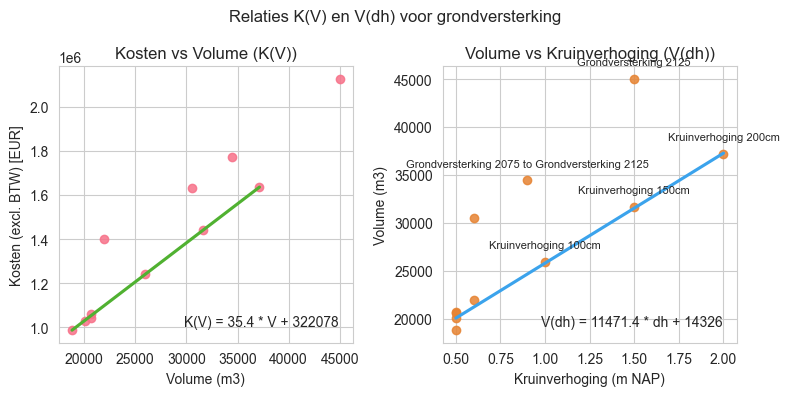

In [18]:
# compute sum of volumes for each alternative
for name, dimension in volume_cost_df_soil.iterrows():
    volume_cost_df_soil.loc[name, 'Volume (m3)'] = (
        dimension['V1b'] + dimension['V2b'] + dimension['V3'] + dimension['V4'] + dimension['V5']
    )

volume_cost_df_soil['Kruinverhoging'] = [
    0.6, 1.5,
    0.5, 1.0, 1.5, 2.0,
    0.6, 0.9,
    0.5, 0.5, 0.5,
]


fit_data = volume_cost_df_soil.loc[volume_cost_df_soil.index.str.contains("Kruinverhoging")]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Panel 1: K(V)
ax = axes[0]
ax.scatter(
    volume_cost_df_soil['Volume (m3)'],
    volume_cost_df_soil['Kosten (excl. BTW)'],
    color=colors[0],
    alpha=0.85,
    label='Alternatieven',
)
sns.regplot(
    x='Volume (m3)',
    y='Kosten (excl. BTW)',
    data=fit_data,
    ax=ax,
    scatter=False,
    color=colors[4],
    ci=None,
    line_kws={'label': 'Lineaire fit (K(V))'},
)
slope_kv, intercept_kv = np.polyfit(
    fit_data['Volume (m3)'],
    fit_data['Kosten (excl. BTW)'],
    1,
)
print(f"K(V) = {slope_kv} * V + {intercept_kv}")
K_V_soil = (slope_kv, intercept_kv)
ax.set_title('Kosten vs Volume (K(V))')
ax.set_xlabel('Volume (m3)')
ax.set_ylabel('Kosten (excl. BTW) [EUR]')
#add formula at right bottom corner of plot
ax.text(0.95, 0.05, f"K(V) = {slope_kv:.1f} * V + {intercept_kv:.0f}", transform=ax.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')

# Panel 2: V(dh)
ax = axes[1]
ax.scatter(
    volume_cost_df_soil['Kruinverhoging'],
    volume_cost_df_soil['Volume (m3)'],
    color=colors[1],
    alpha=0.85,
    label='Alternatieven',
)
sns.regplot(
    x='Kruinverhoging',
    y='Volume (m3)',
    data=fit_data,
    ax=ax,
    scatter=False,
    color=colors[8],
    ci=None,
    line_kws={'label': 'Lineaire fit (V(dh))'},
)
slope_vdh, intercept_vdh = np.polyfit(
    fit_data['Kruinverhoging'],
    fit_data['Volume (m3)'],
    1,
)
print(f"V(dh) = {slope_vdh} * dh + {intercept_vdh}")
V_dh_soil = (slope_vdh, intercept_vdh)

# Add labels for larger crest increases
for i, row in volume_cost_df_soil.iterrows():
    if row['Kruinverhoging'] > 0.6:
        ax.annotate(
            i,
            (row['Kruinverhoging'], row['Volume (m3)']),
            textcoords='offset points',
            xytext=(0, 10),
            ha='center',
            fontsize=8,
        )

ax.set_title('Volume vs Kruinverhoging (V(dh))')
ax.set_xlabel('Kruinverhoging (m NAP)')
ax.set_ylabel('Volume (m3)')
ax.text(0.95, 0.05, f"V(dh) = {slope_vdh:.1f} * dh + {intercept_vdh:.0f}", transform=ax.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')

fig.suptitle('Relaties K(V) en V(dh) voor grondversterking')
fig.tight_layout()

### Constructie
We doen dezelfde afleiding voor constructies om het aan te vullen volume te bepalen

In [5]:
## SETTINGS ## 
files = ['ontwerpvarianten constructief/kostenoverzicht_damwand15m_verankerd.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 2a.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 2b.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht_damwand15m_verankerd.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 3a.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 3b.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 3d.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 3d.xlsx',
         'ontwerpvariant grond gestacked/kostenoverzicht grond 3 aanlegprofiel.xlsx',
         ]

names = ["Verankerde damwand 2025",
         "Ophogen kruin + Taludverflauwing + Oplassen damwand 2075",
         "Ophogen kruin + Taludverflauwing + Plaatsen L-wanden 2075",
         "L-wand op kruin 2075",
         "Ophogen kruin + Oplassen + Buispalen bijplaatsen 2125",
         "Ophogen kruin + Plaatsen L-wanden 2125",
         "Ophogen kruin + Kistdam in binnenteen 2125",
         "Ophogen kruin + Kistdam in kruin + Afschrijven damwand 2125",
         "Grondversterking 2125",
         ]

#  unit prices for custom structures:
unit_prices = {'oplassen variabel per meter damwand per strekkende meter': 300, #o.b.v. prijzen korte damwand (zwaarder profiel). 
               'oplassen vaste kosten per strekkende meter': 280 * 1.5, #o.b.v. unit price stalen gording UNP240. Keer 1.5 voor extra complexiteit
               'L-wand 1.5 meter hoog per strekkende meter': 200, #o.b.v. kosten bij agri-beton.nl (keerwand 150x200x78)
               'Buispalen bijplaatsen per strekkende meter': (7000 / 2.8),  # EU/st / h.o.h. 7000 per buispaal, 2.8m per buispaal
               'Kistdam in binnenteen per strekkende meter':6000, #   Lev/aanbr. kistdam, AZ36, inheid. 15m (B=4m) kost 10000, daar halen we de bestaande damwand vanaf (4000)
               'Kistdam in kruin per strekkende meter': 13000, #  Lev/aanbr. kistdam, AZ36, inheid. 20m (B=4m)
               'Afbranden bestaande damwand per strekkende meter': 200,  #nog checken,
                }

 
alternatives = dict(zip(names, files))

dike = DikeModel(complexity = 'gemiddelde maatregel')

#load costs for all alternatives
cost_dataframes_per_alternative = {}
for name, file in alternatives.items():
    cost_dataframes_per_alternative[name] = pd.read_excel(working_dir / file, sheet_name='Kosten')

#dimensions for all alternatives
dimensions = {}
for name, df in cost_dataframes_per_alternative.items():
    dimensions[name] = get_dimensions_dict_from_df(df)

vaklengte = dimensions['Verankerde damwand 2025']['structure']['Vaklengte'].copy()
# #update costs to include the custom structure costs. These costs are ignored here as it is about deriving the relationship between volume and costs for the soil works. Same for vastgoed.
# for name, dimension in dimensions.items():
#     if name == "Ophogen kruin + Taludverflauwing + Oplassen damwand 2075":
#           etc. all are ignored.

#recomputation of plain costs for all alternatives
cost_summaries = {}
full_cost_dicts = {}
new_dimensions = {}
for name, dimension in dimensions.items():
    cost_summaries[name], full_cost_dicts[name], new_dimensions[name] = modified_cost_computation(dike, dimension)

df_all_costs = pd.concat(cost_summaries.values(), axis=1)
df_all_costs.columns = cost_summaries.keys()
#add (ruw) to the column names of df_all_costs
df_all_costs.columns = [col + " (ruw)" for col in df_all_costs.columns]





K(V) = 45.18322635984883 * V + 19811.642431342385
V(dh) = 6614.22702127614 * dh + 11385.050760739967


Text(0.5, 1.02, 'Relaties K(V) en V(dh) voor constructieve maatregelen')

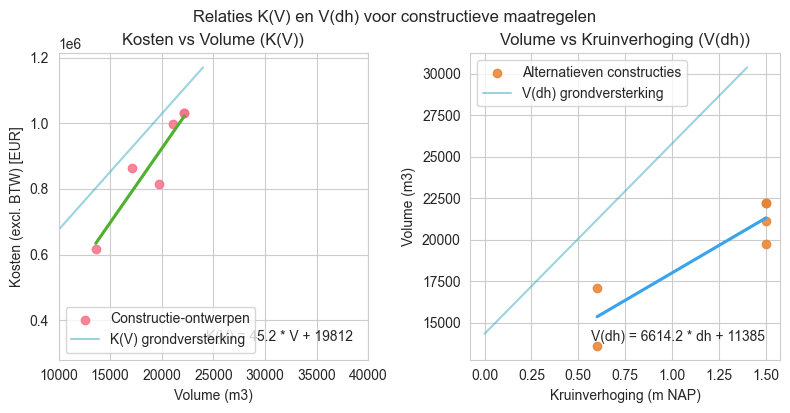

In [ ]:
volume_total = {}
cost_total = {}
for name, dimension in new_dimensions.items():
    volume_total[name] = (
        dimension['ground']['V1b'] + dimension['ground']['V2b'] + dimension['ground']['V3'] + dimension['ground']['V4'] + dimension['ground']['V5']
    )
    cost_total[name] = cost_summaries[name]['Kosten excl. BTW'].sum()

volume_cost_df_structure = pd.DataFrame({'Volume (m3)': volume_total, 'Kosten excl. BTW (€)': cost_total})
volume_cost_df_structure = volume_cost_df_structure.drop(
    ['Verankerde damwand 2025', 'L-wand op kruin 2075', 'Grondversterking 2125'],
    axis=0,
    errors='ignore',
)
volume_cost_df_structure['Kruinverhoging'] = [0.6, 0.6, 1.5, 1.5, 1.5, 1.5]

point_color = '#1f77b4'
comparison_color = '#ff7f0e'
fit_color = '#d62728'
fit_data = volume_cost_df_structure.copy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Panel 1: K(V)
ax = axes[0]
ax.scatter(
    volume_cost_df_structure['Volume (m3)'],
    volume_cost_df_structure['Kosten excl. BTW (€)'],
    color=colors[0],
    alpha=0.85,
    label='Constructie-ontwerpen',
)
sns.regplot(
    x='Volume (m3)',
    y='Kosten excl. BTW (€)',
    data=fit_data,
    ax=ax,
    scatter=False,
    color=colors[4],
    ci=None,
    line_kws={'label': 'Lineaire fit (K(V))'},
)
#add relation for grondversterking
ax.plot(np.arange(0,25000, 1000), K_V_soil[0] * np.arange(0, 25000, 1000) + K_V_soil[1], color=colors[7], alpha=0.5, label='K(V) grondversterking')
slope_kv, intercept_kv = np.polyfit(
    fit_data['Volume (m3)'],
    fit_data['Kosten excl. BTW (€)'],
    1,
)
print(f"K(V) = {slope_kv} * V + {intercept_kv}")
K_V_structure = (slope_kv, intercept_kv)
ax.set_title('Kosten vs Volume (K(V))')
ax.set_xlabel('Volume (m3)')
ax.set_ylabel('Kosten (excl. BTW) [EUR]')
ax.text(
    0.95,
    0.05,
    f"K(V) = {slope_kv:.1f} * V + {intercept_kv:.0f}",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='bottom',
    horizontalalignment='right',
)

ax.legend(loc='best')

# Panel 2: V(dh)
ax = axes[1]
ax.scatter(
    volume_cost_df_structure['Kruinverhoging'],
    volume_cost_df_structure['Volume (m3)'],
    color=colors[1],
    alpha=0.85,
    label='Alternatieven constructies',
)
#plot derived function of K(V) for grondversterking for reference, give alpha=0.5
ax.plot(np.arange(0,1.5, 0.2), V_dh_soil[0] * np.arange(0,1.5, 0.2)+ V_dh_soil[1], color=colors[7], alpha=0.5, label='V(dh) grondversterking')
ax.plot()
sns.regplot(
    x='Kruinverhoging',
    y='Volume (m3)',
    data=fit_data,
    ax=ax,
    scatter=False,
    color=colors[8],
    ci=None,
    line_kws={'label': 'Lineaire fit (V(dh))'},
)
slope_vdh, intercept_vdh = np.polyfit(
    fit_data['Kruinverhoging'],
    fit_data['Volume (m3)'],
    1,
)
V_dh_structure = (slope_vdh, intercept_vdh)
print(f"V(dh) = {slope_vdh} * dh + {intercept_vdh}")
ax.set_title('Volume vs Kruinverhoging (V(dh))')
ax.set_xlabel('Kruinverhoging (m NAP)')
ax.set_ylabel('Volume (m3)')
ax.text(
    0.95,
    0.05,
    f"V(dh) = {slope_vdh:.1f} * dh + {intercept_vdh:.0f}",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='bottom',
    horizontalalignment='right',
)
ax.legend(loc='best')

fig.tight_layout()

fig.suptitle('Relaties K(V) en V(dh) voor constructieve maatregelen', y=1.02)

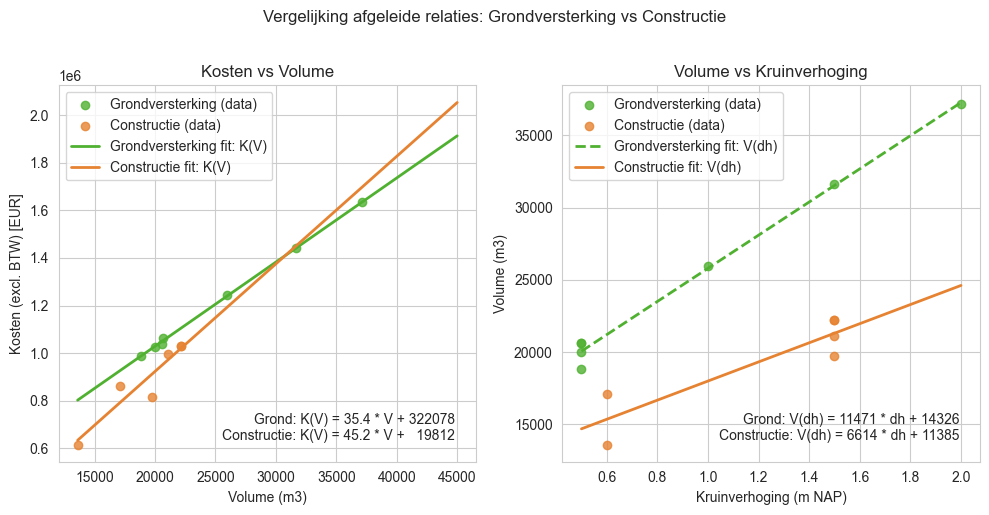

In [49]:
# Combined comparison figure: soil vs constructie
if 'Kruinverhoging' not in volume_cost_df_structure.columns:
    volume_cost_df_structure['Kruinverhoging'] = [0.6, 0.6, 1.5, 1.5, 1.5, 1.5]

soil_color = colors[4]
structure_color = colors[1]
soil_fit_color = colors[4]
structure_fit_color = colors[1]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Panel 1: Kosten - Volume
ax = axes[0]
ax.scatter(
    volume_cost_df_soil.loc[volume_cost_df_soil.index.str.contains('Kruinverhoging'),'Volume (m3)'],
    volume_cost_df_soil.loc[volume_cost_df_soil.index.str.contains('Kruinverhoging'),'Kosten (excl. BTW)'],
    color=soil_color,
    alpha=0.8,
    label='Grondversterking (data)',
)
ax.scatter(
    volume_cost_df_structure['Volume (m3)'],
    volume_cost_df_structure['Kosten excl. BTW (€)'],
    color=structure_color,
    alpha=0.8,
    label='Constructie (data)',
)

x_min = min(volume_cost_df_soil['Volume (m3)'].min(), volume_cost_df_structure['Volume (m3)'].min())
x_max = max(volume_cost_df_soil['Volume (m3)'].max(), volume_cost_df_structure['Volume (m3)'].max())
x_line = np.linspace(x_min, x_max, 200)

ax.plot(
    x_line,
    K_V_soil[0] * x_line + K_V_soil[1],
    color=soil_fit_color,
    linewidth=2,
    linestyle='-',
    label='Grondversterking fit: K(V)',
)
ax.plot(
    x_line,
    K_V_structure[0] * x_line + K_V_structure[1],
    color=structure_fit_color,
    linewidth=2,
    linestyle='-',
    label='Constructie fit: K(V)',
)
ax.text(
    0.95, 0.05, f"Grond: K(V) = {K_V_soil[0]:.1f} * V + {K_V_soil[1]:.0f}\nConstructie: K(V) = {K_V_structure[0]:.1f} * V +   {K_V_structure[1]:.0f}",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='bottom',
    horizontalalignment='right',
)

ax.set_title('Kosten vs Volume')
ax.set_xlabel('Volume (m3)')
ax.set_ylabel('Kosten (excl. BTW) [EUR]')
ax.legend(loc='best')

# Panel 2: Volume - Kruinverhoging
ax = axes[1]
ax.scatter(
    volume_cost_df_soil.loc[volume_cost_df_soil.index.str.contains('Kruinverhoging'),'Kruinverhoging'],
    volume_cost_df_soil.loc[volume_cost_df_soil.index.str.contains('Kruinverhoging'),'Volume (m3)'],
    color=soil_color,
    alpha=0.8,
    label='Grondversterking (data)',
)
ax.scatter(
    volume_cost_df_structure['Kruinverhoging'],
    volume_cost_df_structure['Volume (m3)'],
    color=structure_color,
    alpha=0.8,
    label='Constructie (data)',
)

dh_min = min(volume_cost_df_soil['Kruinverhoging'].min(), volume_cost_df_structure['Kruinverhoging'].min())
dh_max = max(volume_cost_df_soil['Kruinverhoging'].max(), volume_cost_df_structure['Kruinverhoging'].max())
dh_line = np.linspace(dh_min, dh_max, 200)

ax.plot(
    dh_line,
    V_dh_soil[0] * dh_line + V_dh_soil[1],
    color=soil_fit_color,
    linewidth=2,
    linestyle='--',
    label='Grondversterking fit: V(dh)',
)
ax.plot(
    dh_line,
    V_dh_structure[0] * dh_line + V_dh_structure[1],
    color=structure_fit_color,
    linewidth=2,
    linestyle='-',
    label='Constructie fit: V(dh)',
)

ax.text(
    0.95, 0.05, f"Grond: V(dh) = {V_dh_soil[0]:.0f} * dh + {V_dh_soil[1]:.0f}\nConstructie: V(dh) = {V_dh_structure[0]:.0f} * dh + {V_dh_structure[1]:.0f}",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='bottom',
    horizontalalignment='right',
)
ax.set_title('Volume vs Kruinverhoging')
ax.set_xlabel('Kruinverhoging (m NAP)')
ax.set_ylabel('Volume (m3)')
ax.legend(loc='best')

fig.suptitle('Vergelijking afgeleide relaties: Grondversterking vs Constructie', y=1.02)
fig.tight_layout()

In [52]:
print(K_V_soil)
print(V_dh_soil)
print(K_V_structure)
print(V_dh_structure)
print(df_all_costs_with_increments_soil['Grondversterking 2025 (ruw)'].sum())

(35.35484753346291, 322077.9547159534)
(11471.387096774197, 14325.854838709674)
(45.18322635984883, 19811.642431342385)
(6614.22702127614, 11385.050760739967)
1317010.2719987128
